# Notebook 05: Revenue-Neutral Tax Shift Simulation

**Core Hypothesis Test**: If Cook County eliminated all taxes on improvements
and raised the tax rate on sites to maintain the same total revenue, would
the majority of homeowners pay lower property taxes?

This notebook implements the project's Columns 6-11 comparison.

Three tax scenarios are compared:
- **Current**: Tax on (land + improvement) at current class-based rates
- **Scenario A (Col 8)**: Flat rate on total value (no classification)
- **Scenario B (Col 9)**: Land-only tax at a single flat rate
- **Scenario C (Col 11)**: Land-only tax keeping current classification system

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

In [4]:
# Load decomposed assessment data
assessment = pd.read_parquet("../data/processed/assessment_decomposed.parquet")

with open("../data/processed/feature_config.json") as f:
    config = json.load(f)

CLASS_COL = config["class_col"]

print(f"Properties: {len(assessment):,}")
print(f"Columns: {assessment.columns.tolist()}")

Properties: 1,100,150
Columns: ['meta_pin', 'meta_class', 'meta_township_code', 'meta_nbhd_code', 'char_land_sf', 'char_bldg_sf', 'assessment_level', 'is_homeowner', 'pred_total_value', 'pred_site_value_adj', 'pred_improvement_value', 'site_value_ratio', 'ccao_land_mv', 'ccao_bldg_mv', 'ccao_total_mv', 'ccao_site_ratio', 'meta_certified_land', 'meta_certified_bldg', 'loc_latitude', 'loc_longitude', 'hedonic_site_value', 'hedonic_site_ratio']


## 1. Define the Cook County Classification System

Cook County uses a classification system where different property types
are assessed at different percentages of market value. This is unique to
Cook County (most IL counties use a flat 33.33%).

In [5]:
# Cook County assessment levels (% of market value)
# Source: Cook County Classification Ordinance
ASSESSMENT_LEVELS = {
    # Residential (Class 2)
    "200": 0.10,  # Vacant land
    "202": 0.10, "203": 0.10, "204": 0.10, "205": 0.10,
    "206": 0.10, "207": 0.10, "208": 0.10, "209": 0.10,
    "210": 0.10, "211": 0.10, "212": 0.10,
    "234": 0.10, "278": 0.10, "295": 0.10,
    # Commercial/Industrial (Class 5) — if present in data
    "500": 0.25, "501": 0.25, "516": 0.25, "517": 0.25,
    "522": 0.25, "523": 0.25, "525": 0.25, "526": 0.25,
    "527": 0.25, "528": 0.25, "529": 0.25, "530": 0.25,
    "535": 0.25, "550": 0.25, "590": 0.25,
}

# Default for unknown classes
DEFAULT_LEVEL = 0.10

# Single-family homeowner classes (the population the hypothesis targets)
HOMEOWNER_CLASSES = ["202", "203", "204", "205", "206", "207", "208", "209"]


def get_assessment_level(prop_class):
    """Get the Cook County assessment level for a property class."""
    return ASSESSMENT_LEVELS.get(str(prop_class), DEFAULT_LEVEL)


assessment["assessment_level"] = assessment[CLASS_COL].astype(str).map(
    lambda x: get_assessment_level(x)
)

# Tag homeowner properties
assessment["is_homeowner"] = assessment[CLASS_COL].astype(str).isin(HOMEOWNER_CLASSES)

print(f"Homeowner properties: {assessment['is_homeowner'].sum():,} "
      f"({100*assessment['is_homeowner'].mean():.1f}%)")

Homeowner properties: 672,719 (61.1%)


## 2. Compute Current Assessed Values and Tax Bills

Assessed Value = Market Value × Assessment Level

Tax Bill = Assessed Value × Equalization Factor × Tax Rate

The equalization factor is set by the Illinois Department of Revenue
to bring Cook County's median assessment level to 33.33%.

In [6]:
# Illinois State Equalization Factor for Cook County
# This changes annually — use the most recent available
# 2023 factor: approximately 2.9627 (check for your data year)
EQUALIZATION_FACTOR = 2.9627  # UPDATE with correct year's factor
print(f"Using equalization factor: {EQUALIZATION_FACTOR}")

# === Column 6: Current Property Tax Bill ===

# Step 1: Current assessed value (using current classification)
assessment["current_av_land"] = (
    assessment["pred_site_value_adj"] * assessment["assessment_level"]
)
assessment["current_av_improvement"] = (
    assessment["pred_improvement_value"] * assessment["assessment_level"]
)
assessment["current_av_total"] = (
    assessment["current_av_land"] + assessment["current_av_improvement"]
)

# Step 2: Equalized Assessed Value (EAV)
assessment["current_eav"] = assessment["current_av_total"] * EQUALIZATION_FACTOR

# Step 3: Tax bill (we need a tax rate)
# The tax rate varies by location (tax code). If we have it:
if "other_tax_bill_rate" in assessment.columns:
    # Tax rate is usually expressed as a percentage
    # Check the scale — could be 0.08 (8%) or 8.0 (8%)
    median_rate = assessment["other_tax_bill_rate"].median()
    if median_rate > 1:
        # Likely expressed as percentage (e.g., 8.5)
        assessment["tax_rate"] = assessment["other_tax_bill_rate"] / 100
    else:
        assessment["tax_rate"] = assessment["other_tax_bill_rate"]

    # If tax rate is missing, use county median
    county_median_rate = assessment["tax_rate"].median()
    assessment["tax_rate"] = assessment["tax_rate"].fillna(county_median_rate)
else:
    # Use an approximate county-wide average rate (~8-9% in Cook County)
    assessment["tax_rate"] = 0.085
    county_median_rate = 0.085

assessment["col6_current_tax"] = assessment["current_eav"] * assessment["tax_rate"]

print("=== Current Tax Bill Distribution ===")
print(assessment["col6_current_tax"].describe())

Using equalization factor: 2.9627
=== Current Tax Bill Distribution ===
count   1100150.00
mean       9779.06
std        6561.56
min         617.73
25%        5751.95
50%        7978.10
75%       11469.52
max       47614.53
Name: col6_current_tax, dtype: float64


In [7]:
# Calculate total current revenue (our revenue-neutral target)
TOTAL_CURRENT_REVENUE = assessment["col6_current_tax"].sum()
print(f"Total Current Property Tax Revenue: ${TOTAL_CURRENT_REVENUE:,.0f}")

Total Current Property Tax Revenue: $10,758,427,652


## 3. Scenario A (Column 8): Flat Rate on Total Value

What if ALL parcels were assessed at 1/3 market value (eliminating
classification) and taxed at a single rate?

In [8]:
# Column 7: Assessed value at 1/3 market price (no classification)
FLAT_ASSESSMENT_LEVEL = 1/3

assessment["col7_flat_av"] = assessment["pred_total_value"] * FLAT_ASSESSMENT_LEVEL

# Column 8: Revenue-neutral single tax rate on total value
total_flat_av = assessment["col7_flat_av"].sum()
SCENARIO_A_RATE = TOTAL_CURRENT_REVENUE / total_flat_av

assessment["col8_scenario_a_tax"] = assessment["col7_flat_av"] * SCENARIO_A_RATE

print(f"=== Scenario A: Flat Rate on Total Value ===")
print(f"  Flat assessment level: {FLAT_ASSESSMENT_LEVEL:.4f} (1/3)")
print(f"  Revenue-neutral tax rate: {SCENARIO_A_RATE:.6f} ({100*SCENARIO_A_RATE:.4f}%)")
print(f"  Total revenue check: ${assessment['col8_scenario_a_tax'].sum():,.0f}")
print(f"  (Target: ${TOTAL_CURRENT_REVENUE:,.0f})")

=== Scenario A: Flat Rate on Total Value ===
  Flat assessment level: 0.3333 (1/3)
  Revenue-neutral tax rate: 0.075549 (7.5549%)
  Total revenue check: $10,758,427,652
  (Target: $10,758,427,652)


## 4. Scenario B (Column 9): Land-Only Tax, Single Flat Rate

**THE KEY SCENARIO** — What if we eliminated the tax on improvements and
taxed ONLY the site value at a flat rate (1/3 of site market value)?

In [9]:
# Column 9: Land-only, flat assessment at 1/3 of site value
assessment["col9_site_av"] = assessment["pred_site_value_adj"] * FLAT_ASSESSMENT_LEVEL

total_site_av = assessment["col9_site_av"].sum()
SCENARIO_B_RATE = TOTAL_CURRENT_REVENUE / total_site_av

assessment["col9_scenario_b_tax"] = assessment["col9_site_av"] * SCENARIO_B_RATE

print(f"=== Scenario B: Land-Only Tax (Flat Rate) ===")
print(f"  Assessment base: site value only \u00d7 1/3")
print(f"  Revenue-neutral tax rate: {SCENARIO_B_RATE:.6f} ({100*SCENARIO_B_RATE:.4f}%)")
print(f"  Rate multiplier vs current: {SCENARIO_B_RATE/county_median_rate:.2f}x")
print(f"  Total revenue check: ${assessment['col9_scenario_b_tax'].sum():,.0f}")

=== Scenario B: Land-Only Tax (Flat Rate) ===
  Assessment base: site value only × 1/3
  Revenue-neutral tax rate: 0.317874 (31.7874%)
  Rate multiplier vs current: 3.74x
  Total revenue check: $10,758,427,652


## 5. Scenario C (Column 11): Land-Only Tax, Keeping Classification

In [10]:
# Column 10: Site assessed using current classification system
assessment["col10_classified_site_av"] = (
    assessment["pred_site_value_adj"] * assessment["assessment_level"]
)

# Column 11: Revenue-neutral rate on classified site values
total_classified_site_av = assessment["col10_classified_site_av"].sum()
SCENARIO_C_RATE = TOTAL_CURRENT_REVENUE / total_classified_site_av

assessment["col11_scenario_c_tax"] = (
    assessment["col10_classified_site_av"] * SCENARIO_C_RATE
)

print(f"=== Scenario C: Land-Only Tax (Classified) ===")
print(f"  Assessment base: site value only \u00d7 class-based level")
print(f"  Revenue-neutral tax rate: {SCENARIO_C_RATE:.6f} ({100*SCENARIO_C_RATE:.4f}%)")
print(f"  Total revenue check: ${assessment['col11_scenario_c_tax'].sum():,.0f}")

=== Scenario C: Land-Only Tax (Classified) ===
  Assessment base: site value only × class-based level
  Revenue-neutral tax rate: 1.059581 (105.9581%)
  Total revenue check: $10,758,427,652


## 6. HYPOTHESIS TEST: Compare Current vs Proposed Tax Bills

In [11]:
# === For each scenario, compute the change from current bill ===
for scenario, col in [("A", "col8_scenario_a_tax"),
                      ("B", "col9_scenario_b_tax"),
                      ("C", "col11_scenario_c_tax")]:
    diff_col = f"diff_{scenario}"
    assessment[diff_col] = assessment[col] - assessment["col6_current_tax"]
    assessment[f"pct_change_{scenario}"] = (
        assessment[diff_col] / assessment["col6_current_tax"].replace(0, np.nan) * 100
    )
    assessment[f"winner_{scenario}"] = assessment[diff_col] < 0  # Lower bill = winner

In [12]:
# === CORE RESULT: What percentage of homeowners would pay less? ===
print("=" * 70)
print("  HYPOTHESIS TEST RESULTS")
print("  Would the majority of homeowners pay lower property taxes?")
print("=" * 70)

homeowners = assessment[assessment["is_homeowner"]].copy()

for scenario, label in [
    ("A", "Flat rate on total value (no classification)"),
    ("B", "Land-only tax, flat rate (THE MAIN PROPOSAL)"),
    ("C", "Land-only tax, keeping classification"),
]:
    winners = homeowners[f"winner_{scenario}"].sum()
    total = len(homeowners)
    pct = 100 * winners / total
    median_savings = homeowners.loc[homeowners[f"winner_{scenario}"], f"diff_{scenario}"].median()
    median_increase = homeowners.loc[~homeowners[f"winner_{scenario}"], f"diff_{scenario}"].median()

    print(f"\n--- Scenario {scenario}: {label} ---")
    print(f"  Homeowners paying LESS:  {winners:>8,} / {total:,} = {pct:.1f}%")
    print(f"  Homeowners paying MORE:  {total - winners:>8,} / {total:,} = {100-pct:.1f}%")
    if not np.isnan(median_savings):
        print(f"  Median savings (winners):  ${abs(median_savings):>8,.0f}")
    if not np.isnan(median_increase):
        print(f"  Median increase (losers):  ${median_increase:>8,.0f}")

    hypothesis = "SUPPORTED" if pct > 50 else "NOT SUPPORTED"
    print(f"  >>> Majority hypothesis: {hypothesis} <<<")

  HYPOTHESIS TEST RESULTS
  Would the majority of homeowners pay lower property taxes?

--- Scenario A: Flat rate on total value (no classification) ---
  Homeowners paying LESS:   454,439 / 672,719 = 67.6%
  Homeowners paying MORE:   218,280 / 672,719 = 32.4%
  Median savings (winners):  $       0
  Median increase (losers):  $       0
  >>> Majority hypothesis: SUPPORTED <<<

--- Scenario B: Land-only tax, flat rate (THE MAIN PROPOSAL) ---
  Homeowners paying LESS:   386,576 / 672,719 = 57.5%
  Homeowners paying MORE:   286,143 / 672,719 = 42.5%
  Median savings (winners):  $   1,656
  Median increase (losers):  $   2,302
  >>> Majority hypothesis: SUPPORTED <<<

--- Scenario C: Land-only tax, keeping classification ---
  Homeowners paying LESS:   386,576 / 672,719 = 57.5%
  Homeowners paying MORE:   286,143 / 672,719 = 42.5%
  Median savings (winners):  $   1,656
  Median increase (losers):  $   2,302
  >>> Majority hypothesis: SUPPORTED <<<


## 7. Distributional Analysis

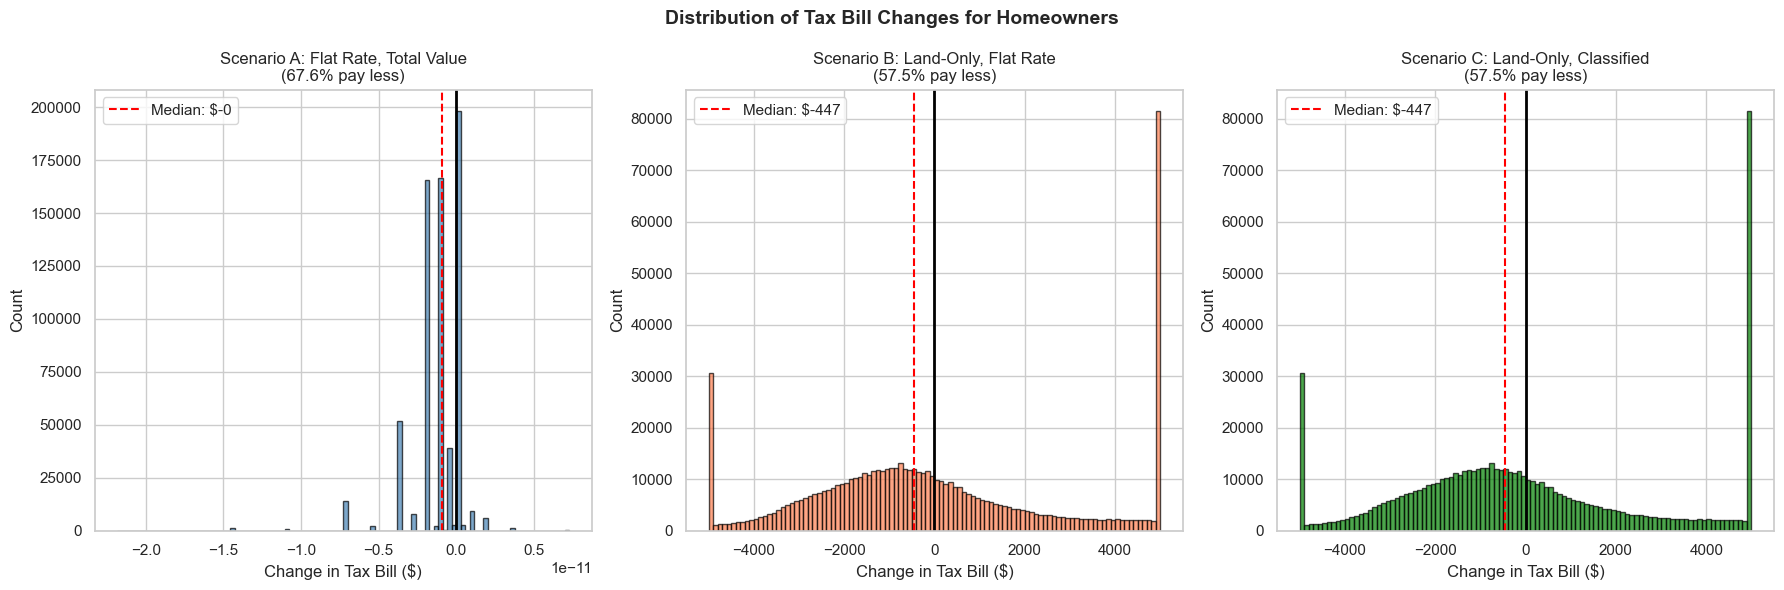

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scenarios = [
    ("A", "Flat Rate, Total Value", "steelblue"),
    ("B", "Land-Only, Flat Rate", "coral"),
    ("C", "Land-Only, Classified", "green"),
]

for ax, (scenario, label, color) in zip(axes, scenarios):
    diff = homeowners[f"diff_{scenario}"].dropna()
    diff_clipped = diff.clip(-5000, 5000)

    ax.hist(diff_clipped, bins=100, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(0, color="black", linewidth=2, linestyle="-")
    ax.axvline(diff.median(), color="red", linestyle="--",
               label=f"Median: ${diff.median():,.0f}")

    pct_winners = 100 * (diff < 0).mean()
    ax.set_title(f"Scenario {scenario}: {label}\n({pct_winners:.1f}% pay less)")
    ax.set_xlabel("Change in Tax Bill ($)")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Distribution of Tax Bill Changes for Homeowners",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/05_tax_change_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

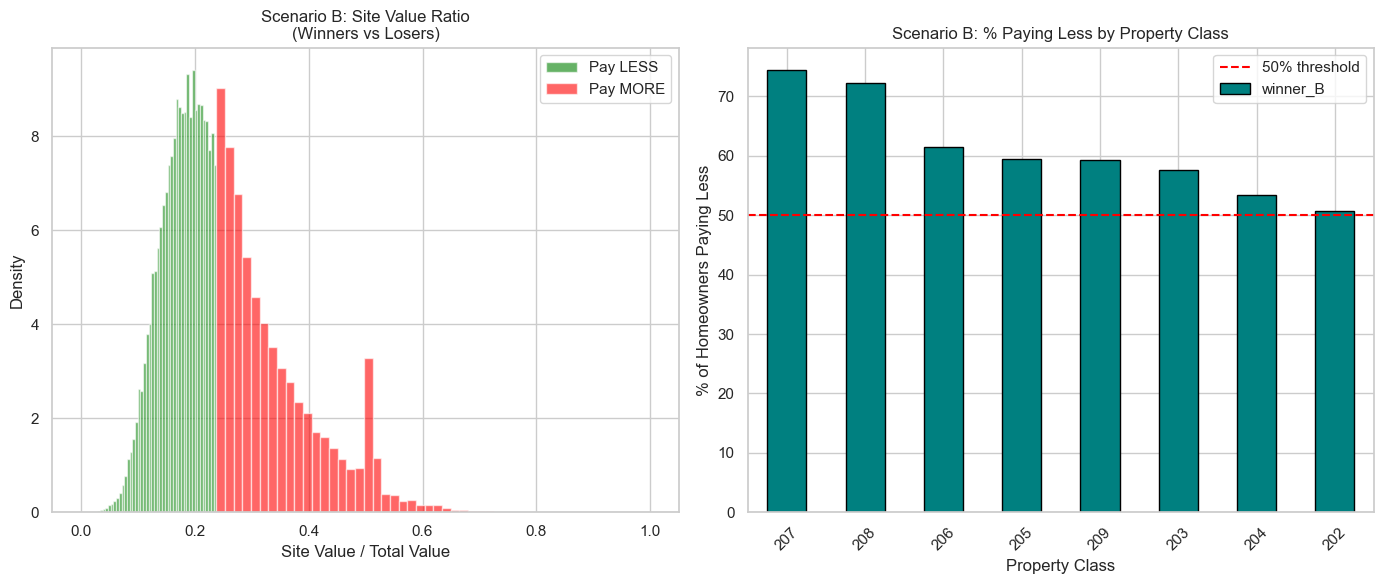

In [14]:
# === Who wins and who loses? Profile by improvement-to-land ratio ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Focus on Scenario B (the main proposal)
ax = axes[0]
if "site_value_ratio" in homeowners.columns:
    winners_b = homeowners[homeowners["winner_B"]]
    losers_b = homeowners[~homeowners["winner_B"]]

    ax.hist(winners_b["site_value_ratio"].dropna().clip(0, 1),
            bins=50, alpha=0.6, label="Pay LESS", color="green", density=True)
    ax.hist(losers_b["site_value_ratio"].dropna().clip(0, 1),
            bins=50, alpha=0.6, label="Pay MORE", color="red", density=True)
    ax.set_title("Scenario B: Site Value Ratio\n(Winners vs Losers)")
    ax.set_xlabel("Site Value / Total Value")
    ax.set_ylabel("Density")
    ax.legend()

# By property class
ax = axes[1]
class_winner_pct = (
    homeowners.groupby(CLASS_COL)["winner_B"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
class_winner_pct.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
ax.axhline(50, color="red", linestyle="--", label="50% threshold")
ax.set_title("Scenario B: % Paying Less by Property Class")
ax.set_ylabel("% of Homeowners Paying Less")
ax.set_xlabel("Property Class")
ax.legend()
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/figures/05_winner_loser_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Geographic Distribution of Tax Changes

=== Scenario B: Results by Township ===

                    n_properties  pct_winners_B  median_change_B  median_current_tax
meta_township_code                                                                  
27                          9580          95.44         -4239.19            12854.76
31                         32983          93.12         -2009.74             6340.23
33                          2517          90.90         -5579.65            21143.80
13                         20293          78.93         -1249.92             4970.63
20                         19276          78.76         -1243.38             7038.71
21                         19445          78.51         -2453.66             8790.15
28                          9728          77.94         -1905.61             9311.59
18                         13336          77.17         -1331.17             6895.69
15                          8121          76.86          -741.18             5972.22
39                      

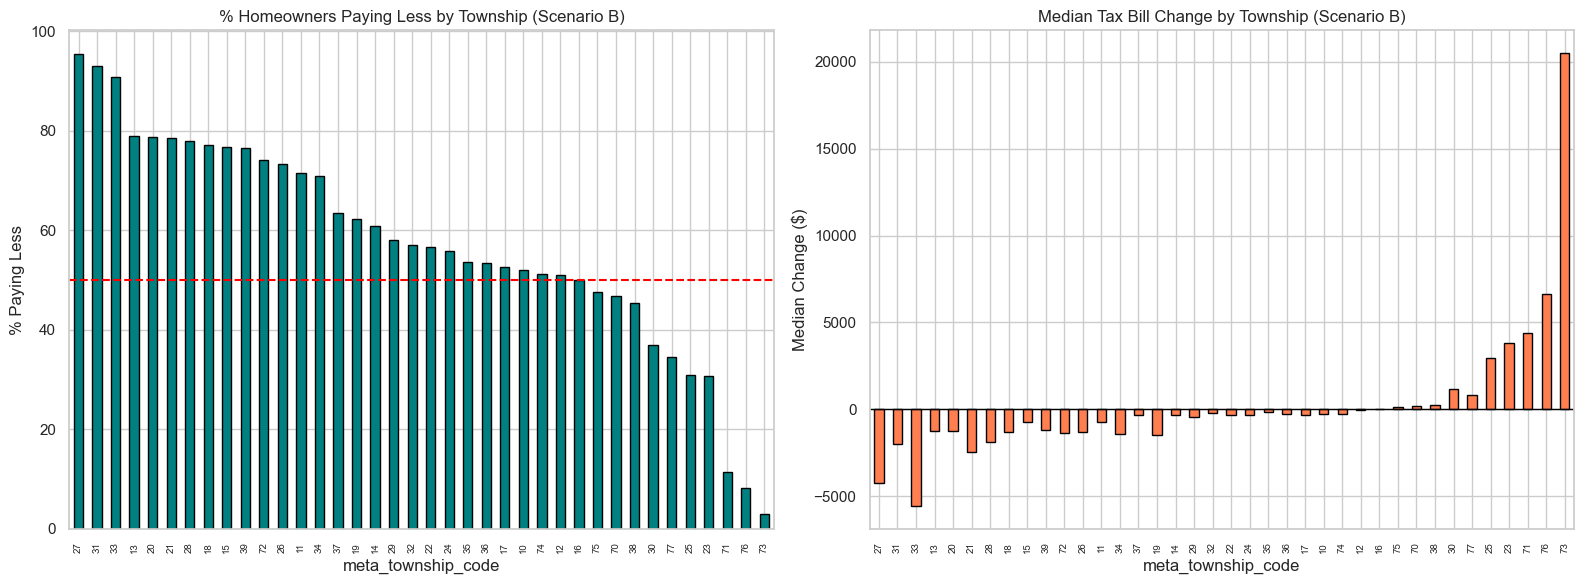

In [15]:
if "meta_township_code" in homeowners.columns:
    twp_analysis = homeowners.groupby("meta_township_code").agg(
        n_properties=("meta_pin", "count"),
        pct_winners_B=("winner_B", "mean"),
        median_change_B=("diff_B", "median"),
        median_current_tax=("col6_current_tax", "median"),
    ).sort_values("pct_winners_B", ascending=False)

    twp_analysis["pct_winners_B"] *= 100

    print("=== Scenario B: Results by Township ===\n")
    print(twp_analysis.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    twp_analysis["pct_winners_B"].plot(kind="bar", ax=ax, color="teal", edgecolor="black")
    ax.axhline(50, color="red", linestyle="--")
    ax.set_title("% Homeowners Paying Less by Township (Scenario B)")
    ax.set_ylabel("% Paying Less")
    ax.tick_params(axis="x", rotation=90, labelsize=7)

    ax = axes[1]
    twp_analysis["median_change_B"].plot(kind="bar", ax=ax, color="coral", edgecolor="black")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Median Tax Bill Change by Township (Scenario B)")
    ax.set_ylabel("Median Change ($)")
    ax.tick_params(axis="x", rotation=90, labelsize=7)

    plt.tight_layout()
    plt.savefig("../outputs/figures/05_township_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Save Results for Classification Model (Notebook 06)

In [16]:
# Save the full simulation results
sim_output_cols = [
    "meta_pin", CLASS_COL, "meta_township_code", "meta_nbhd_code",
    "is_homeowner", "assessment_level",
    "char_land_sf", "char_bldg_sf",
    "pred_total_value", "pred_site_value_adj", "pred_improvement_value",
    "site_value_ratio",
    "col6_current_tax", "col8_scenario_a_tax", "col9_scenario_b_tax",
    "col11_scenario_c_tax",
    "diff_A", "diff_B", "diff_C",
    "pct_change_A", "pct_change_B", "pct_change_C",
    "winner_A", "winner_B", "winner_C",
]
sim_output_cols = [c for c in sim_output_cols if c in assessment.columns]

assessment[sim_output_cols].to_parquet(
    "../data/processed/tax_simulation_results.parquet", index=False
)

# Summary statistics
summary = {
    "total_properties": len(assessment),
    "total_homeowners": int(assessment["is_homeowner"].sum()),
    "total_current_revenue": float(TOTAL_CURRENT_REVENUE),
    "scenario_a_rate": float(SCENARIO_A_RATE),
    "scenario_b_rate": float(SCENARIO_B_RATE),
    "scenario_c_rate": float(SCENARIO_C_RATE),
}

for scenario in ["A", "B", "C"]:
    hw = homeowners[f"winner_{scenario}"]
    summary[f"scenario_{scenario}_pct_homeowners_pay_less"] = float(100 * hw.mean())
    summary[f"scenario_{scenario}_median_savings"] = float(
        homeowners.loc[hw, f"diff_{scenario}"].median()
    )

import json
with open("../outputs/reports/simulation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved: ../data/processed/tax_simulation_results.parquet")
print("Saved: ../outputs/reports/simulation_summary.json")

Saved: ../data/processed/tax_simulation_results.parquet
Saved: ../outputs/reports/simulation_summary.json
